In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import (
    CountVectorizer,
    TfidfVectorizer
)

from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

plt.style.use('ggplot')
df = pd.read_csv("../data/raw/raw_analyst_ratings.csv")
df.head()

df.shape

df.info()

df.describe(include='all')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\redea\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


<class 'pandas.DataFrame'>
RangeIndex: 1407328 entries, 0 to 1407327
Data columns (total 6 columns):
 #   Column      Non-Null Count    Dtype
---  ------      --------------    -----
 0   Unnamed: 0  1407328 non-null  int64
 1   headline    1407328 non-null  str  
 2   url         1407328 non-null  str  
 3   publisher   1407328 non-null  str  
 4   date        1407328 non-null  str  
 5   stock       1407328 non-null  str  
dtypes: int64(1), str(5)
memory usage: 64.4 MB


,Unnamed: 0,headline,url,publisher,date,stock
count,1.407328e+06,1407328,1407328,1407328,1407328,1407328
unique,NaN,845770,883429,1034,39957,6204
top,NaN,Benzinga's Top Upgrades,https://www.benzinga.com/news/20/03/15538835/s...,Paul Quintaro,2020-03-12 00:00:00,MRK
freq,NaN,5449,1704,228373,1766,3333
mean,7.072454e+05,NaN,NaN,NaN,NaN,NaN
std,4.081009e+05,NaN,NaN,NaN,NaN,NaN
min,0.000000e+00,NaN,NaN,NaN,NaN,NaN
25%,3.538128e+05,NaN,NaN,NaN,NaN,NaN
50%,7.072395e+05,NaN,NaN,NaN,NaN,NaN
75%,1.060710e+06,NaN,NaN,NaN,NaN,NaN


In [3]:
df.isnull().sum()

Unnamed: 0    0
headline      0
url           0
publisher     0
date          0
stock         0
dtype: int64

In [4]:
df['headline_length'] = df['headline'].astype(str).apply(len)
df['headline_length'].describe()

count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_length, dtype: float64

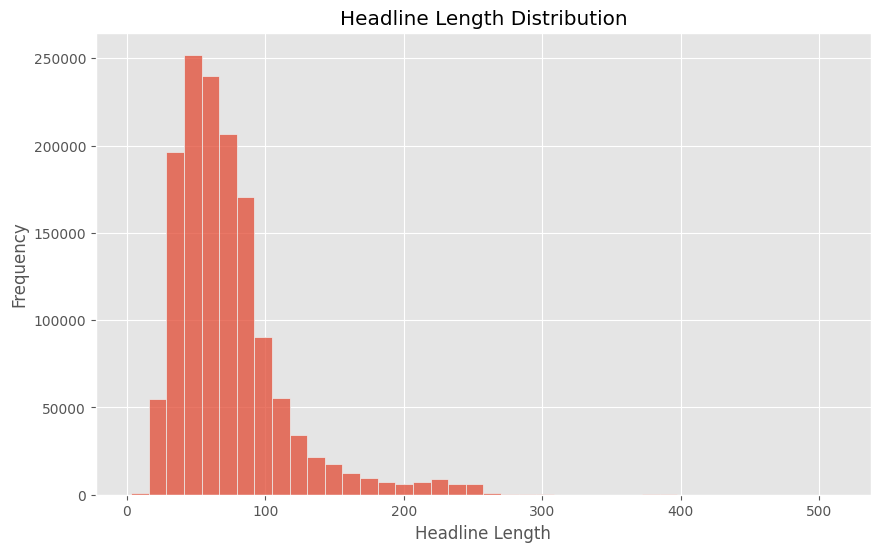

In [5]:
plt.figure(figsize=(10,6))

sns.histplot(
    df['headline_length'],
    bins=40
)

plt.title("Headline Length Distribution")
plt.xlabel("Headline Length")
plt.ylabel("Frequency")

plt.show()

## 📊 Summary of Descriptive Analysis

The exploratory analysis revealed key characteristics of the financial news dataset:

- Headlines are generally short and information-dense, reflecting fast-paced financial reporting.
- A small number of publishers contribute the majority of news articles, indicating concentrated information sources.
- News publication shows clear time-based patterns, with noticeable spikes around market events.
- Most articles are published during active trading hours, suggesting strong linkage to market activity.
- Common terms highlight financial themes such as earnings, price targets, and stock movements.

Overall, the dataset is clean and well-structured, providing a strong foundation for sentiment analysis and stock price correlation in later stages.

## 📰 Publisher Analysis

This section focuses on understanding the role of news publishers in shaping financial narratives within the dataset.

We aim to analyze:

- The most active publishers in terms of article volume
- Distribution of news contribution across different sources
- Whether a small group of publishers dominates financial news generation
- Potential extraction of publisher domains (if email-based publishers exist)

Understanding publisher behavior is important because:
- It helps identify information concentration in financial reporting
- It may reveal bias or dominance of certain news sources
- It provides context for weighting sentiment reliability in later analysis

This analysis will be visualized using:
- Bar charts of top publishers
- Frequency distributions of article counts
- Domain-level aggregation (if applicable)

In [6]:
publisher_counts = (
    df['publisher']
    .value_counts()
    .head(15)
)

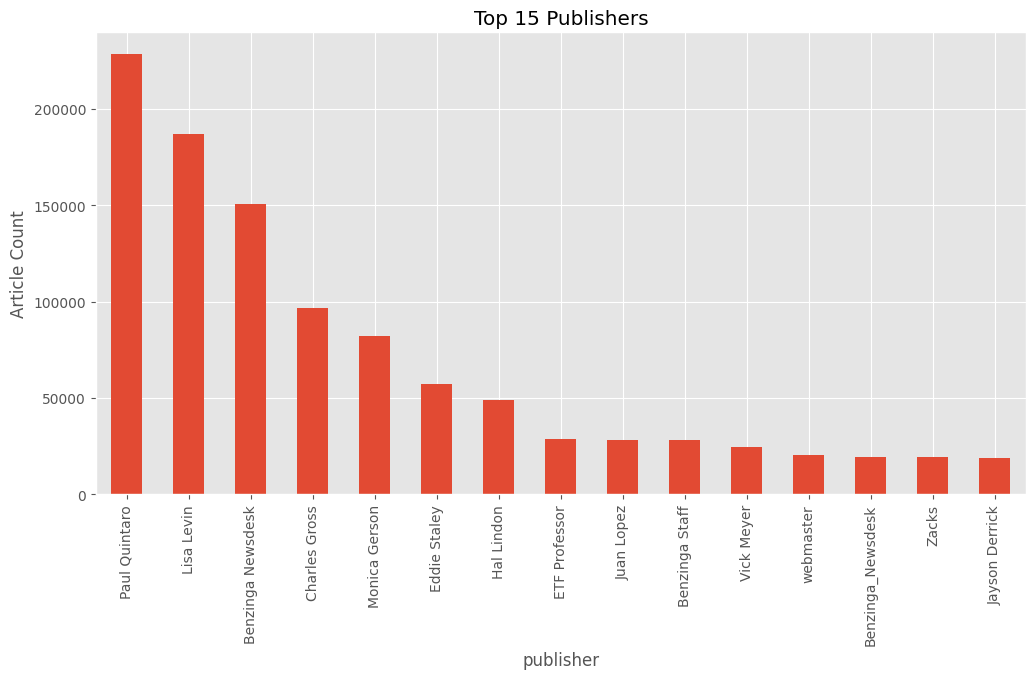

In [7]:
plt.figure(figsize=(12,6))

publisher_counts.plot(
    kind='bar'
)

plt.title("Top 15 Publishers")
plt.ylabel("Article Count")

plt.show()

## Extract Email Domains

In [9]:
df['publisher_domain'] = (
    df['publisher']
    .astype(str)
    .str.extract(r'@([\w\.-]+)')
)
df['publisher_domain'].value_counts().head(10)

publisher_domain
benzinga.com              7937
gmail.com                  139
andyswan.com                 5
investdiva.com               2
tothetick.com                2
eosdetroit.io                1
forextraininggroup.com       1
stockmetrix.net              1
Name: count, dtype: int64

## Date & Time Analysis

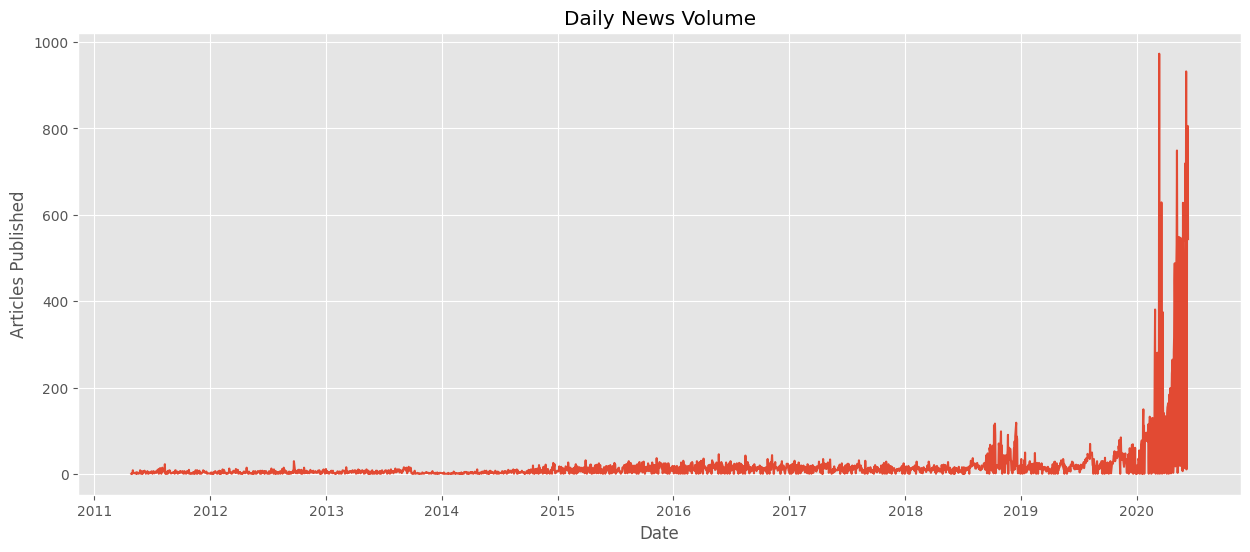

In [13]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')

daily_news = (
    df.groupby(df['date'].dt.date)
    .size()
)
plt.figure(figsize=(15,6))

daily_news.plot()

plt.title("Daily News Volume")
plt.xlabel("Date")
plt.ylabel("Articles Published")

plt.show()

## Publishing Hour Analysis

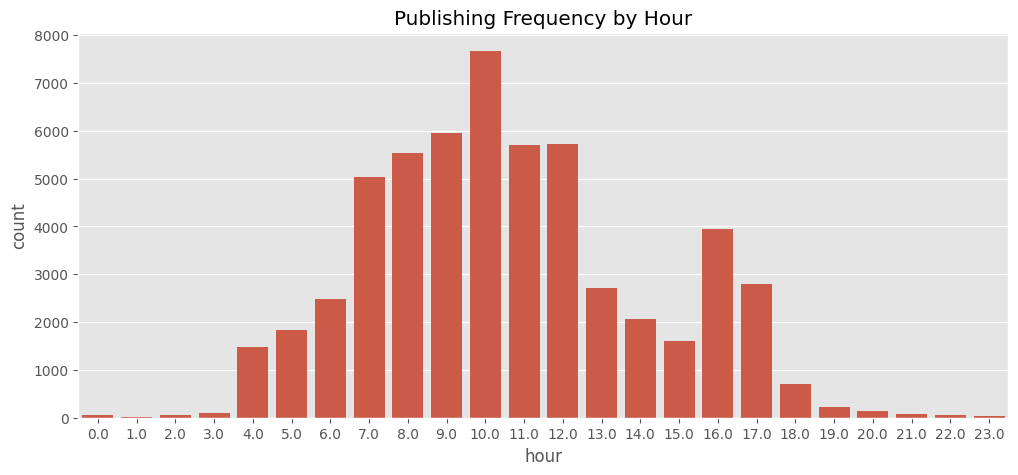

In [14]:
df['hour'] = df['date'].dt.hour

plt.figure(figsize=(12,5))

sns.countplot(
    x='hour',
    data=df
)

plt.title("Publishing Frequency by Hour")

plt.show()

## 🧠 TF-IDF Keyword Extraction

In this section, we apply **TF-IDF (Term Frequency–Inverse Document Frequency)** to extract the most important words and phrases from financial news headlines.

### 🎯 Objective

The goal is to identify key financial terms that frequently appear in headlines but carry strong informational value. These keywords help us understand dominant market narratives and recurring themes in the dataset.

---

### 📌 Why TF-IDF?

Unlike simple word frequency, TF-IDF helps us:
- Reduce the impact of common words (e.g., "stock", "market")
- Highlight more meaningful financial terms (e.g., "earnings beat", "price target", "acquisition")
- Identify words that are important within specific contexts rather than across all documents

---

### ⚙️ Approach

We will:
- Convert headlines into numerical feature vectors
- Apply TF-IDF vectorization
- Extract top-scoring keywords based on importance
- Analyze the most significant terms in financial news reporting

---

### 📊 Expected Output

This analysis will produce:
- A ranked list of important financial keywords
- Insights into dominant market themes
- Better understanding of news-driven sentiment signals

---

### 📌 Importance for Next Steps

The extracted keywords will later help in:
- Sentiment analysis interpretation
- Topic modeling
- Linking news content with stock price movements

In [15]:
tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=25
)

X = tfidf.fit_transform(
    df['headline'].astype(str)
)

scores = pd.DataFrame({
    'keyword': tfidf.get_feature_names_out(),
    'score': X.sum(axis=0).A1
})

scores = scores.sort_values(
    by='score',
    ascending=False
)

scores.head(15)

,keyword,score
18,stocks,112715.765383
10,market,81165.121298
5,earnings,74507.890155
17,shares,73259.639259
23,vs,65256.315804
15,reports,63895.450132
21,update,61250.591783
6,eps,60702.677270
2,benzinga,58064.202486
1,announces,54500.925488


## Word Cloud

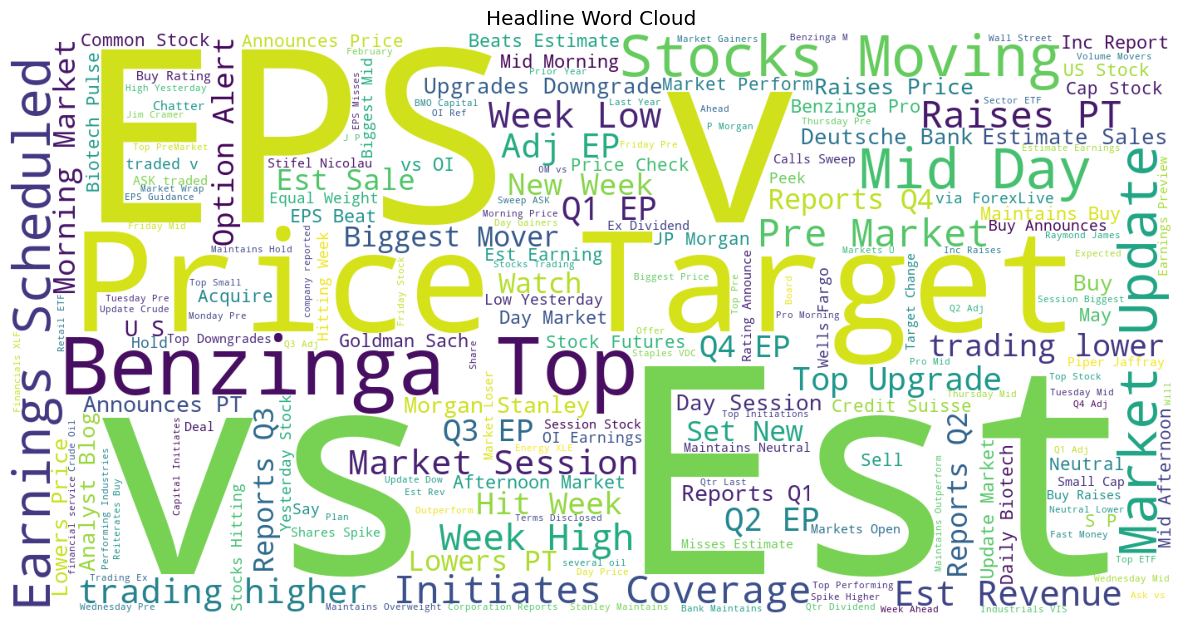

In [16]:
text = " ".join(
    df['headline'].astype(str)
)

wordcloud = WordCloud(
    width=1400,
    height=700,
    background_color='white'
).generate(text)

plt.figure(figsize=(15,8))

plt.imshow(wordcloud)

plt.axis('off')

plt.title("Headline Word Cloud")

plt.show()

## Topic Modeling

In [17]:
vectorizer = CountVectorizer(
    stop_words='english',
    ngram_range=(2,2),
    max_features=20
)

X = vectorizer.fit_transform(
    df['headline']
)

phrases = pd.DataFrame({
    'phrase': vectorizer.get_feature_names_out(),
    'count': X.sum(axis=0).A1
})

phrases.sort_values(
    by='count',
    ascending=False
)

,phrase,count
0,52 week,51006
10,price target,47274
16,stocks moving,40044
8,mid day,37324
7,market update,33101
4,earnings scheduled,32055
5,initiates coverage,28993
9,pre market,28393
14,raises pt,27213
3,companies trading,23170
